# SECTION 01 — Imports

In [111]:
import os
from pathlib import Path
import json
import time
import requests
import re

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from tqdm.notebook import tqdm

import essentia
import essentia.standard as es

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# SECTION 02 - Load Data

In [112]:
top40 = pd.read_csv("top40_billboard_dataset.csv") # 
apple_df = pd.read_csv("usable_apple_matches_v2.csv")  # only after current job finishes

In [143]:
# Folder for downloaded Apple preview clips
PREVIEW_DIR = Path("preview_clips")
PREVIEW_DIR.mkdir(exist_ok=True)

# Folder where Essentia model files are stored
MODEL_DIR = Path("essentia_models")

usable_apple_df = pd.read_csv("usable_apple_matches_v2.csv")
usable_apple_df.shape

(3783, 24)

# SECTION 03 - Load Genre Metadata

In [141]:
with open(
    "essentia_models/genre_discogs400-discogs-effnet-1.json"
) as f:
    metadata = json.load(f)

labels = metadata["classes"]

print(len(labels))

400


# SECTION 04 - Load Tensorflow Models

## MusicCNN Embeddings (ALL)

In [144]:
# MusiCNN embedder used for valence/arousal model
musicnn_embedder = es.TensorflowPredictMusiCNN(
    graphFilename=str(MODEL_DIR / "msd-musicnn-1.pb"),
    output="model/dense/BiasAdd"
)

# Valence/arousal model
deam_model = es.TensorflowPredict2D(
    graphFilename=str(MODEL_DIR / "deam-msd-musicnn-2.pb"),
    input="model/Placeholder",
    output="model/Identity"
)

# EffNet embedder used for Discogs genre model
effnet_embedder = es.TensorflowPredictEffnetDiscogs(
    graphFilename=str(MODEL_DIR / "discogs-effnet-bs64-1.pb"),
    output="PartitionedCall:1"
)

# Discogs400 genre classifier
genre_model = es.TensorflowPredict2D(
    graphFilename=str(MODEL_DIR / "genre_discogs400-discogs-effnet-1.pb"),
    input="serving_default_model_Placeholder",
    output="PartitionedCall:0"
)

print("Models loaded.")

Models loaded.


## Danceability

In [ ]:
dance_model = es.TensorflowPredict2D(
    graphFilename="essentia_models/danceability-msd-musicnn-1.pb",
    output="model/Softmax"
)

## Valence / Arousal

In [ ]:
deam_model = es.TensorflowPredict2D(
    graphFilename="essentia_models/deam-msd-musicnn-2.pb",
    output="model/Identity"
)

## Discogs Embeddings

In [ ]:
effnet_embedder = es.TensorflowPredictEffnetDiscogs(
    graphFilename="essentia_models/discogs-effnet-bs64-1.pb",
    output="PartitionedCall:1"
)

## Discogs Genre Classifier

In [ ]:
genre_model = es.TensorflowPredict2D(
    graphFilename="essentia_models/genre_discogs400-discogs-effnet-1.pb",
    input="serving_default_model_Placeholder",
    output="PartitionedCall:0"
)

# SECTION 05 — Helper Functions

## Safe filename

In [145]:
def safe_filename(text):
    """
    Convert song/artist text into a safe filename.
    """
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    text = text.strip("_")
    return text[:120]

## Download preview

In [146]:
def download_preview(row, preview_dir=PREVIEW_DIR, timeout=15):
    """
    Download one Apple preview clip from preview_url.
    Returns:
        preview_file path
        download_status
    """
    song = row["search_song"]
    artist = row["search_artist"]
    url = row["preview_url"]

    if pd.isna(url) or url == "":
        return None, "missing_url"

    apple_id = row.get("apple_track_id", row.name)

    filename = (
        f"{safe_filename(artist)}__"
        f"{safe_filename(song)}__"
        f"{apple_id}.m4a"
    )

    filepath = preview_dir / filename

    # Skip if already downloaded
    if filepath.exists() and filepath.stat().st_size > 0:
        return str(filepath), "already_exists"

    try:
        response = requests.get(url, timeout=timeout)

        if response.status_code != 200:
            return None, f"status_{response.status_code}"

        with open(filepath, "wb") as f:
            f.write(response.content)

        if filepath.stat().st_size == 0:
            filepath.unlink(missing_ok=True)
            return None, "empty_file"

        return str(filepath), "downloaded"

    except Exception as e:
        return None, f"error_{type(e).__name__}"

## Get Top Genres

In [147]:
def get_top_genres(labels, genre_mean, n=5):
    """
    Return top n detailed Discogs genre predictions.
    """
    top_indices = np.argsort(genre_mean)[::-1][:n]

    genre_features = {}

    for rank, idx in enumerate(top_indices, start=1):
        genre_features[f"genre_{rank}"] = labels[idx]
        genre_features[f"genre_{rank}_score"] = float(genre_mean[idx])

    return genre_features


## Clean Genre Family Name + Aggregate Genre Families

In [148]:
def clean_genre_family_name(family):
    """
    Convert genre family text into clean column suffix.
    """
    family = family.lower()
    family = family.replace("&", "and")
    family = family.replace("/", "_")
    family = re.sub(r"[^a-z0-9]+", "_", family)
    family = family.strip("_")
    return family

In [149]:
def aggregate_genre_families(labels, genre_mean):
    """
    Aggregate 400 detailed Discogs genre probabilities into broad families.
    Example:
        Rock---Alternative Rock -> genre_family_rock
        Hip Hop---Trap -> genre_family_hip_hop
    """
    family_scores = {}

    for label, score in zip(labels, genre_mean):
        family = label.split("---")[0]
        family_clean = clean_genre_family_name(family)
        col = f"genre_family_{family_clean}"

        family_scores[col] = family_scores.get(col, 0) + float(score)

    return family_scores

## Adjust tempo

In [151]:
def adjust_tempo_final(row):
    """
    Create adjusted tempo while keeping raw tempo.

    Logic:
    - Raw Essentia tempo often suffers from half/double-time ambiguity.
    - For Billboard tracks, 145–180 BPM is often double-time.
    - But strong electronic/rock tracks may genuinely be fast, so we keep those.
    """
    bpm = row["tempo_bpm"]

    electronic = row.get("genre_family_electronic", 0)
    rock = row.get("genre_family_rock", 0)

    adjusted = bpm
    reason = "unchanged"

    # Likely double-time region
    if 145 <= bpm <= 180:
        if electronic >= 0.80 or rock >= 0.80:
            adjusted = bpm
            reason = "kept_high_bpm_strong_electronic_or_rock"
        else:
            adjusted = bpm / 2
            reason = "halved_145_180_likely_double_time"

    # Extremely high tempos are usually double-time in this dataset
    elif bpm > 180:
        adjusted = bpm / 2
        reason = "halved_over_180_extreme_bpm"

    return pd.Series({
        "tempo_bpm_raw": bpm,
        "tempo_bpm_adjusted": adjusted,
        "tempo_adjustment_reason": reason
    })

# SECTION 06 - Main Feature Extraction Function

In [150]:
def extract_audio_features(filename, labels):
    """
    Extract final audio features from one Apple preview clip.

    Important:
    - Danceability is intentionally excluded because both tested models saturated.
    - Exact key is intentionally excluded because it is noisy and not analytically useful.
    - Mode and key_strength are kept as lightweight harmonic features.
    """
    features = {
        "preview_filename": filename
    }

    try:
        # =========================
        # Load audio at two sample rates
        # =========================

        # 44.1k audio for traditional audio descriptors
        audio_44100 = es.MonoLoader(
            filename=filename,
            sampleRate=44100
        )()

        # 16k audio for TensorFlow models
        audio_16000 = es.MonoLoader(
            filename=filename,
            sampleRate=16000,
            resampleQuality=4
        )()

        features["preview_duration_sec"] = float(len(audio_44100) / 44100)

        # =========================
        # Rhythm / tempo
        # =========================
        rhythm = es.RhythmExtractor2013(method="multifeature")
        bpm, beats, beat_confidence, _, _ = rhythm(audio_44100)

        # Keep raw tempo. Adjustment will happen later during cleaning.
        features["tempo_bpm"] = float(bpm)
        features["beat_confidence"] = float(beat_confidence)

        # =========================
        # Loudness
        # =========================
        features["rms_loudness"] = float(es.RMS()(audio_44100))

        # =========================
        # Mode / key strength
        # =========================
        key_extractor = es.KeyExtractor()
        key, mode, key_strength = key_extractor(audio_44100)

        # Exact key is not saved because it is noisy and hard to interpret.
        features["mode"] = mode
        features["key_strength"] = float(key_strength)

        # =========================
        # Spectral / timbre features
        # =========================
        frame_size = 2048
        hop_size = 1024

        window = es.Windowing(type="hann")
        spectrum = es.Spectrum()
        centroid = es.Centroid(range=22050)
        rolloff = es.RollOff(sampleRate=44100)

        centroids = []
        rolloffs = []

        for frame in es.FrameGenerator(
            audio_44100,
            frameSize=frame_size,
            hopSize=hop_size
        ):
            spec = spectrum(window(frame))
            centroids.append(centroid(spec))
            rolloffs.append(rolloff(spec))

        features["spectral_centroid_mean"] = float(np.mean(centroids))
        features["spectral_rolloff_mean"] = float(np.mean(rolloffs))

        # =========================
        # Valence / arousal
        # =========================
        musicnn_embeddings = musicnn_embedder(audio_16000)

        deam_preds = deam_model(musicnn_embeddings)
        deam_mean = deam_preds.mean(axis=0)

        features["valence"] = float(deam_mean[0])
        features["arousal"] = float(deam_mean[1])

        # =========================
        # Genre features
        # =========================
        effnet_embeddings = effnet_embedder(audio_16000)

        genre_preds = genre_model(effnet_embeddings)
        genre_mean = genre_preds.mean(axis=0)

        # Top 5 detailed genres
        top_genre_features = get_top_genres(
            labels=labels,
            genre_mean=genre_mean,
            n=5
        )
        features.update(top_genre_features)

        # Broad genre-family probabilities
        family_features = aggregate_genre_families(
            labels=labels,
            genre_mean=genre_mean
        )
        features.update(family_features)

        # Convert any leftover numpy scalar values to regular floats
        for k, v in list(features.items()):
            if isinstance(v, np.generic):
                features[k] = float(v)

        features["audio_feature_error"] = None

        return features

    except Exception as e:
        return {
            "preview_filename": filename,
            "audio_feature_error": str(e)
        }

# SECTION 07 — Single Song Test

### Download test

In [ ]:
features = extract_audio_features(
    "preview_clips/test_preview.m4a",
    labels
)

pd.Series(features)

In [37]:
test_df = usable_apple_df.head(5).copy()

test_download_results = []

for idx, row in tqdm(test_df.iterrows(), total=len(test_df)):
    preview_file, download_status = download_preview(row)
    
    test_download_results.append({
        "index": idx,
        "search_song": row["search_song"],
        "search_artist": row["search_artist"],
        "preview_file": preview_file,
        "download_status": download_status
    })

test_download_df = pd.DataFrame(test_download_results)
test_download_df

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:01<00:00,  3.29it/s]


,index,search_song,search_artist,preview_file,download_status
0,0,"""1 Step Forward, 3 Steps Back""",Olivia Rodrigo,preview_clips/olivia_rodrigo__1_step_forward_3...,downloaded
1,1,"""1, 2 Step""",Ciara Featuring Missy Elliott,preview_clips/ciara_featuring_missy_elliott__1...,downloaded
2,2,"""1, 2, 3, 4""",Plain White T's,preview_clips/plain_white_t_s__1_2_3_4__160588...,downloaded
3,3,"""10,000 Hours""",Dan + Shay & Justin Bieber,preview_clips/dan_shay_justin_bieber__10_000_h...,downloaded
4,4,"""Awful, Beautiful Life""",Darryl Worley,preview_clips/darryl_worley__awful_beautiful_l...,downloaded


In [38]:
test_df[["search_song", "search_artist", "preview_url"]]

,search_song,search_artist,preview_url
0,"""1 Step Forward, 3 Steps Back""",Olivia Rodrigo,https://audio-ssl.itunes.apple.com/itunes-asse...
1,"""1, 2 Step""",Ciara Featuring Missy Elliott,https://audio-ssl.itunes.apple.com/itunes-asse...
2,"""1, 2, 3, 4""",Plain White T's,https://audio-ssl.itunes.apple.com/itunes-asse...
3,"""10,000 Hours""",Dan + Shay & Justin Bieber,https://audio-ssl.itunes.apple.com/itunes-asse...
4,"""Awful, Beautiful Life""",Darryl Worley,https://audio-ssl.itunes.apple.com/itunes-asse...


In [39]:
import os

len(os.listdir("preview_clips"))

6

In [40]:
from pathlib import Path

test_files = list(Path("preview_clips").glob("*.m4a"))

print("Number of preview files:", len(test_files))
test_files[:10]

Number of preview files: 6


[PosixPath('preview_clips/test_preview.m4a'),
 PosixPath('preview_clips/plain_white_t_s__1_2_3_4__1605885112.0.m4a'),
 PosixPath('preview_clips/dan_shay_justin_bieber__10_000_hours__1576237877.0.m4a'),
 PosixPath('preview_clips/darryl_worley__awful_beautiful_life__1443592008.0.m4a'),
 PosixPath('preview_clips/ciara_featuring_missy_elliott__1_2_step__1674065022.0.m4a'),
 PosixPath('preview_clips/olivia_rodrigo__1_step_forward_3_steps_back__1560735846.0.m4a')]

In [41]:
test_file = test_files[0]

audio = es.MonoLoader(
    filename=str(test_file),
    sampleRate=16000
)()

print(audio.shape)
print(audio[:10])

(479608,)
[-0.09679781 -0.17170496 -0.15364861 -0.1396135  -0.10116211 -0.11903103
 -0.14245255 -0.16964036 -0.18766378 -0.18562336]


### Feature extraction test

In [47]:
test_file = test_files[1]

extract_audio_features(
    filename=str(test_file),
    labels=labels
)

I0000 00:00:1780226729.893601 1484202 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
[   INFO   ] TensorflowPredict: Successfully loaded graph file: `essentia_models/genre_discogs400-discogs-effnet-1.pb`


{'preview_duration_sec': 29.975510204081633,
 'tempo_bpm': 89.63284301757812,
 'beat_confidence': 2.6348624229431152,
 'rms_loudness': 0.2608727812767029,
 'key': 'D',
 'mode': 'major',
 'key_strength': 0.9366236925125122,
 'spectral_centroid_mean': np.float64(2826.1444637900904),
 'spectral_rolloff_mean': np.float64(1084.210110596459),
 'danceability_score': np.float32(0.11198602),
 'not_danceable_score': np.float32(0.888014),
 'valence': np.float32(5.436965),
 'arousal': np.float32(5.027247),
 'genre_1': 'Rock---Pop Rock',
 'genre_1_score': np.float32(0.16895576),
 'genre_2': 'Rock---Alternative Rock',
 'genre_2_score': np.float32(0.14130554),
 'genre_3': 'Rock---Acoustic',
 'genre_3_score': np.float32(0.13932972),
 'genre_4': 'Rock---Neofolk',
 'genre_4_score': np.float32(0.09937097),
 'genre_5': 'Rock---Indie Rock',
 'genre_5_score': np.float32(0.07918194),
 'genre_family_blues': np.float32(0.053546812),
 'genre_family_brass_and_military': np.float32(0.003821565),
 "genre_family_ch

In [48]:
import time
import pandas as pd
from tqdm.notebook import tqdm

benchmark_files = test_files[1:6]

start = time.time()

benchmark_results = []

for file in tqdm(benchmark_files, total=len(benchmark_files)):
    features = extract_audio_features(
        filename=str(file),
        labels=labels
    )
    
    features["preview_file"] = str(file)
    benchmark_results.append(features)

elapsed = time.time() - start

benchmark_features = pd.DataFrame(benchmark_results)

print(f"Total time: {elapsed:.2f} sec")
print(f"Seconds per song: {elapsed / len(benchmark_files):.2f}")
print(f"Estimated hours for 3783 songs: {(elapsed / len(benchmark_files)) * 3783 / 3600:.2f}")

benchmark_features.head()

  0%|          | 0/5 [00:00<?, ?it/s]

Total time: 7.50 sec
Seconds per song: 1.50
Estimated hours for 3783 songs: 1.58


,preview_duration_sec,tempo_bpm,beat_confidence,rms_loudness,key,mode,key_strength,spectral_centroid_mean,spectral_rolloff_mean,danceability_score,...,genre_family_hip_hop,genre_family_jazz,genre_family_latin,genre_family_non_music,genre_family_pop,genre_family_reggae,genre_family_rock,genre_family_stage_and_screen,audio_feature_error,preview_file
0,29.97551,89.632843,2.634862,0.260873,D,major,0.936624,2826.144464,1084.210111,0.111986,...,0.029134,0.005265,0.010116,0.025339,0.083516,0.023637,1.199483,0.002437,None,preview_clips/plain_white_t_s__1_2_3_4__160588...
1,29.92907,178.205811,2.696650,0.247301,Bb,major,0.937904,3112.863702,1233.468614,0.916280,...,0.167848,0.007165,0.081251,0.026035,0.675385,0.016751,0.140071,0.005422,None,preview_clips/dan_shay_justin_bieber__10_000_h...
2,29.92907,112.451279,4.022439,0.248761,D,major,0.941523,2545.897491,1314.309934,0.043089,...,0.001111,0.001728,0.000727,0.025739,0.228829,0.000909,0.723153,0.004464,None,preview_clips/darryl_worley__awful_beautiful_l...
3,29.92907,116.173401,2.469709,0.274486,G,major,0.508867,3324.488946,2381.004724,1.000000,...,0.497635,0.000735,0.010825,0.000528,0.070866,0.003168,0.007899,0.000968,None,preview_clips/ciara_featuring_missy_elliott__1...
4,29.97551,172.265625,0.554861,0.185166,D,major,0.882782,1722.536017,776.578637,0.965231,...,0.042945,0.100163,0.052241,0.014486,0.448652,0.005238,0.152280,0.011177,None,preview_clips/olivia_rodrigo__1_step_forward_3...


In [49]:
for file in test_files:
    print(file)

    result = extract_audio_features(
        filename=str(file),
        labels=labels
    )

    print(
        result["danceability_score"],
        result["not_danceable_score"]
    )

    print()


preview_clips/test_preview.m4a
0.9582068 0.041793328

preview_clips/plain_white_t_s__1_2_3_4__1605885112.0.m4a
0.11198602 0.888014

preview_clips/dan_shay_justin_bieber__10_000_hours__1576237877.0.m4a
0.91627973 0.08372025

preview_clips/darryl_worley__awful_beautiful_life__1443592008.0.m4a
0.043089207 0.95691067

preview_clips/ciara_featuring_missy_elliott__1_2_step__1674065022.0.m4a
0.9999998 1.5962134e-07

preview_clips/olivia_rodrigo__1_step_forward_3_steps_back__1560735846.0.m4a
0.96523124 0.034768816



In [50]:
cols = [
    "tempo_bpm",
    "danceability_score",
    "valence",
    "arousal",
    "rms_loudness",
    "spectral_centroid_mean",
    "genre_1",
    "genre_1_score"
]

benchmark_features[cols]

,tempo_bpm,danceability_score,valence,arousal,rms_loudness,spectral_centroid_mean,genre_1,genre_1_score
0,89.632843,0.111986,5.436965,5.027247,0.260873,2826.144464,Rock---Pop Rock,0.168956
1,178.205811,0.916280,4.820089,5.673097,0.247301,3112.863702,Electronic---Disco Polo,0.370537
2,112.451279,0.043089,6.257137,5.357296,0.248761,2545.897491,"Folk, World, & Country---Country",0.486353
3,116.173401,1.000000,7.023382,5.322175,0.274486,3324.488946,Hip Hop---Trap,0.255818
4,172.265625,0.965231,4.464632,4.418778,0.185166,1722.536017,Pop---Ballad,0.143656


In [51]:
for file in test_files:
    result = extract_audio_features(
        filename=str(file),
        labels=labels
    )

    print("=" * 60)
    print(file.name)
    print("tempo:", round(result["tempo_bpm"], 1))
    print("danceability:", round(result["danceability_score"], 3))
    print("valence:", round(result["valence"], 3))
    print("arousal:", round(result["arousal"], 3))
    print("genre:", result["genre_1"])

test_preview.m4a
tempo: 79.0
danceability: 0.958
valence: 5.86
arousal: 5.441
genre: Rock---Alternative Rock
plain_white_t_s__1_2_3_4__1605885112.0.m4a
tempo: 89.6
danceability: 0.112
valence: 5.437
arousal: 5.027
genre: Rock---Pop Rock
dan_shay_justin_bieber__10_000_hours__1576237877.0.m4a
tempo: 178.2
danceability: 0.916
valence: 4.82
arousal: 5.673
genre: Electronic---Disco Polo
darryl_worley__awful_beautiful_life__1443592008.0.m4a
tempo: 112.5
danceability: 0.043
valence: 6.257
arousal: 5.357
genre: Folk, World, & Country---Country
ciara_featuring_missy_elliott__1_2_step__1674065022.0.m4a
tempo: 116.2
danceability: 1.0
valence: 7.023
arousal: 5.322
genre: Hip Hop---Trap
olivia_rodrigo__1_step_forward_3_steps_back__1560735846.0.m4a
tempo: 172.3
danceability: 0.965
valence: 4.465
arousal: 4.419
genre: Pop---Ballad


In [52]:
for file in test_files:
    result = extract_audio_features(
        filename=str(file),
        labels=labels
    )

    print(file.name)
    print(result["genre_1"])
    print(result["genre_2"])
    print(result["genre_3"])
    print()

test_preview.m4a
Rock---Alternative Rock
Pop---Ballad
Rock---Pop Rock

plain_white_t_s__1_2_3_4__1605885112.0.m4a
Rock---Pop Rock
Rock---Alternative Rock
Rock---Acoustic

dan_shay_justin_bieber__10_000_hours__1576237877.0.m4a
Electronic---Disco Polo
Pop---Europop
Electronic---Eurodance

darryl_worley__awful_beautiful_life__1443592008.0.m4a
Folk, World, & Country---Country
Rock---Country Rock
Pop---Schlager

ciara_featuring_missy_elliott__1_2_step__1674065022.0.m4a
Hip Hop---Trap
Electronic---House
Hip Hop---Cloud Rap

olivia_rodrigo__1_step_forward_3_steps_back__1560735846.0.m4a
Pop---Ballad
Folk, World, & Country---Fado
Pop---K-pop



In [53]:
for file in test_files:
    result = extract_audio_features(
        filename=str(file),
        labels=labels
    )

    print(file.name)
    print("danceability:", result["danceability_score"])
    print("tempo:", result["tempo_bpm"])
    print("beat confidence:", result["beat_confidence"])
    print()

test_preview.m4a
danceability: 0.9582068
tempo: 78.95964050292969
beat confidence: 2.6579442024230957

plain_white_t_s__1_2_3_4__1605885112.0.m4a
danceability: 0.11198602
tempo: 89.63284301757812
beat confidence: 2.6348624229431152

dan_shay_justin_bieber__10_000_hours__1576237877.0.m4a
danceability: 0.91627973
tempo: 178.205810546875
beat confidence: 2.6966497898101807

darryl_worley__awful_beautiful_life__1443592008.0.m4a
danceability: 0.043089207
tempo: 112.45127868652344
beat confidence: 4.022439479827881

ciara_featuring_missy_elliott__1_2_step__1674065022.0.m4a
danceability: 0.9999998
tempo: 116.17340087890625
beat confidence: 2.4697093963623047

olivia_rodrigo__1_step_forward_3_steps_back__1560735846.0.m4a
danceability: 0.96523124
tempo: 172.265625
beat confidence: 0.5548609495162964



In [57]:
test_file = test_files[-1]  # Olivia

audio_16000 = es.MonoLoader(
    filename=str(test_file),
    sampleRate=16000,
    resampleQuality=4
)()

musicnn_embeddings = musicnn_embedder(audio_16000)

dance_preds = dance_model(musicnn_embeddings)

print(dance_preds.shape)

dance_mean = dance_preds.mean(axis=0)

print(dance_mean)

(19, 2)
[0.96523124 0.03476882]


### 100 song download and test

In [59]:
test_download_df = usable_apple_df.head(100).copy()

download_results = []

for idx, row in tqdm(
    test_download_df.iterrows(),
    total=len(test_download_df)
):

    preview_file, download_status = download_preview(row)

    download_results.append({
        "index": idx,
        "preview_file": preview_file,
        "download_status": download_status
    })

download_results_df = pd.DataFrame(download_results)

download_results_df["download_status"].value_counts()

  0%|          | 0/100 [00:00<?, ?it/s]

download_status
downloaded        95
already_exists     5
Name: count, dtype: int64

In [61]:
from pathlib import Path

preview_files = list(
    Path("preview_clips").glob("*.m4a")
)

print(len(preview_files))

101


In [62]:
preview_files = [
    f for f in preview_files
    if f.name != "test_preview.m4a"
]

preview_files = preview_files[:100]

print(len(preview_files))

100


In [63]:
audio_results_100 = []

for file in tqdm(
    preview_files,
    total=len(preview_files)
):

    features = extract_audio_features(
        filename=str(file),
        labels=labels
    )

    features["preview_file"] = file.name

    audio_results_100.append(features)

audio_features_100 = pd.DataFrame(audio_results_100)

  0%|          | 0/100 [00:00<?, ?it/s]

In [65]:
audio_features_100.to_csv(
    "audio_features_100.csv",
    index=False
)

print(audio_features_100.shape)

(100, 40)


In [66]:
audio_features_100["audio_feature_error"].value_counts(dropna=False)

audio_feature_error
None    100
Name: count, dtype: int64

In [67]:
audio_features_100["danceability_score"].describe()

count    100.000000
mean       0.845044
std        0.275393
min        0.001492
25%        0.809666
50%        0.999358
75%        1.000000
max        1.000000
Name: danceability_score, dtype: float64

In [68]:
audio_features_100["tempo_bpm"].describe()

count    100.000000
mean     120.751814
std       26.256255
min       76.503914
25%       99.990141
50%      116.101784
75%      142.420490
max      178.205811
Name: tempo_bpm, dtype: float64

In [69]:
audio_features_100["genre_1"].value_counts().head(20)

genre_1
Pop---K-pop                         13
Rock---Alternative Rock             10
Hip Hop---Trap                      10
Rock---Pop Rock                      7
Electronic---Tropical House          5
Hip Hop---Cloud Rap                  5
Pop---Ballad                         4
Electronic---Synth-pop               3
Funk / Soul---Contemporary R&B       3
Hip Hop---Conscious                  2
Hip Hop---Gangsta                    2
Electronic---House                   2
Hip Hop---Grime                      2
Electronic---Electro House           2
Hip Hop---RnB/Swing                  2
Hip Hop---Crunk                      2
Rock---Indie Rock                    2
Folk, World, & Country---Country     2
Rock---Punk                          1
Electronic---Disco Polo              1
Name: count, dtype: int64

In [70]:
genre_family_cols = [
    col for col in audio_features_100.columns
    if col.startswith("genre_family_")
]

audio_features_100[genre_family_cols].mean().sort_values(ascending=False)

genre_family_electronic                0.491403
genre_family_hip_hop                   0.487430
genre_family_rock                      0.429657
genre_family_pop                       0.253821
genre_family_funk__soul                0.107356
genre_family_folk_world_and_country    0.083718
genre_family_latin                     0.037136
genre_family_reggae                    0.029259
genre_family_blues                     0.016350
genre_family_non_music                 0.015589
genre_family_jazz                      0.014466
genre_family_stage_and_screen          0.008803
genre_family_classical                 0.004898
genre_family_children's                0.004631
genre_family_brass_and_military        0.001208
dtype: float32

In [71]:
audio_features_100["valence"].describe()

count    100.000000
mean       5.559793
std        0.866835
min        3.174302
25%        5.029540
50%        5.582313
75%        6.125743
max        7.553596
Name: valence, dtype: float64

In [72]:
audio_features_100["arousal"].describe()

count    100.000000
mean       5.360807
std        0.602804
min        3.742853
25%        4.941096
50%        5.318830
75%        5.674913
max        6.907878
Name: arousal, dtype: float64

In [73]:
audio_features_100["rms_loudness"].describe()

count    100.000000
mean       0.290460
std        0.062149
min        0.090876
25%        0.259238
50%        0.285033
75%        0.327186
max        0.492957
Name: rms_loudness, dtype: float64

In [ ]:
audio_features_100["spectral_centroid_mean"].describe()

In [74]:
cols = [
    "valence",
    "arousal",
    "rms_loudness",
    "spectral_centroid_mean"
]

audio_features_100[cols].describe()

,valence,arousal,rms_loudness,spectral_centroid_mean
count,100.000000,100.000000,100.000000,100.000000
mean,5.559793,5.360807,0.290460,2988.059330
std,0.866835,0.602804,0.062149,801.728074
min,3.174302,3.742853,0.090876,1073.756332
25%,5.029540,4.941096,0.259238,2392.700373
50%,5.582313,5.318830,0.285033,2977.775647
75%,6.125743,5.674913,0.327186,3407.899439
max,7.553596,6.907878,0.492957,5980.670951


In [79]:
import os

for f in sorted(os.listdir('essentia_models')):
    if "dance" in f.lower():
        print(f)

danceability-discogs-effnet-1.pb
danceability-msd-musicnn-1.pb


In [93]:
dance_effnet_model = es.TensorflowPredict2D(
    graphFilename="essentia_models/danceability-discogs-effnet-1.pb",
    input="model/Placeholder",
    output="model/Softmax"
)
print("loaded!")

loaded!


In [94]:
test_file = test_files[-1]

audio_16000 = es.MonoLoader(
    filename=str(test_file),
    sampleRate=16000,
    resampleQuality=4
)()

effnet_embeddings = effnet_embedder(audio_16000)

print(effnet_embeddings.shape)

(29, 1280)


In [95]:
dance_preds_effnet = dance_effnet_model(
    effnet_embeddings
)

print(dance_preds_effnet.shape)

dance_mean_effnet = dance_preds_effnet.mean(axis=0)

print(dance_mean_effnet)

(29, 2)
[0.3811211 0.6188789]


In [91]:
import os

for f in sorted(os.listdir("essentia_models")):
    print(f)

danceability-discogs-effnet-1.json
danceability-discogs-effnet-1.pb
danceability-msd-musicnn-1.pb
deam-msd-musicnn-2.pb
discogs-effnet-bs64-1.pb
genre_discogs400-discogs-effnet-1.json
genre_discogs400-discogs-effnet-1.pb
msd-musicnn-1.pb


In [98]:
for file in test_files[1:]:

    audio_16000 = es.MonoLoader(
        filename=str(file),
        sampleRate=16000,
        resampleQuality=4
    )()

    # OLD MODEL
    musicnn_embeddings = musicnn_embedder(audio_16000)

    old_preds = dance_model(
        musicnn_embeddings
    ).mean(axis=0)

    # NEW MODEL
    effnet_embeddings = effnet_embedder(audio_16000)

    new_preds = dance_effnet_model(
        effnet_embeddings
    ).mean(axis=0)

    print("=" * 70)
    print(file.name)

    print(
        "OLD:",
        round(float(old_preds[0]), 3),
        round(float(old_preds[1]), 3)
    )

    print(
        "NEW:",
        round(float(new_preds[0]), 3),
        round(float(new_preds[1]), 3)
    )

plain_white_t_s__1_2_3_4__1605885112.0.m4a
OLD: 0.112 0.888
NEW: 0.153 0.847
dan_shay_justin_bieber__10_000_hours__1576237877.0.m4a
OLD: 0.916 0.084
NEW: 0.846 0.154
darryl_worley__awful_beautiful_life__1443592008.0.m4a
OLD: 0.043 0.957
NEW: 0.001 0.999
ciara_featuring_missy_elliott__1_2_step__1674065022.0.m4a
OLD: 1.0 0.0
NEW: 1.0 0.0
olivia_rodrigo__1_step_forward_3_steps_back__1560735846.0.m4a
OLD: 0.965 0.035
NEW: 0.381 0.619


In [99]:
from pathlib import Path
import pandas as pd
from tqdm.notebook import tqdm

# Use the 100 downloaded preview files
preview_files_100 = [
    f for f in Path("preview_clips").glob("*.m4a")
    if f.name != "test_preview.m4a"
]

preview_files_100 = sorted(preview_files_100)[:100]

print(len(preview_files_100))

100


In [100]:
dance_effnet_results_100 = []

for file in tqdm(preview_files_100, total=len(preview_files_100)):

    audio_16000 = es.MonoLoader(
        filename=str(file),
        sampleRate=16000,
        resampleQuality=4
    )()

    effnet_embeddings = effnet_embedder(audio_16000)

    preds = dance_effnet_model(
        effnet_embeddings
    ).mean(axis=0)

    dance_effnet_results_100.append({
        "preview_file": file.name,
        "danceability_effnet": float(preds[0]),
        "not_danceable_effnet": float(preds[1])
    })

dance_effnet_100 = pd.DataFrame(dance_effnet_results_100)

dance_effnet_100.head()

  0%|          | 0/100 [00:00<?, ?it/s]

,preview_file,danceability_effnet,not_danceable_effnet
0,21_savage__3am_on_glenwood__1653012722.0.m4a,0.994535,0.005465
1,akon__sorry_blame_it_on_me__1610800965.0.m4a,0.999708,0.000292
2,amerie__1_thing__153437689.0.m4a,0.999526,0.000474
3,andy_grammer__honey_i_m_good__1780516397.0.m4a,0.999186,0.000814
4,ariana_grande__break_up_with_your_girlfriend_i...,0.998041,0.001959


In [101]:
dance_effnet_100["danceability_effnet"].describe()

count    100.000000
mean       0.729103
std        0.344804
min        0.000997
25%        0.456329
50%        0.957656
75%        0.996730
max        0.999901
Name: danceability_effnet, dtype: float64

Task was destroyed but it is pending!
task: <Task pending name='Task-786' coro=<_async_in_context.<locals>.run_in_context_pre311() done, defined at /opt/miniconda3/envs/music-ai/lib/python3.10/site-packages/ipykernel/utils.py:76> wait_for=<Task pending name='Task-787' coro=<_async_in_context.<locals>.preserve_context() running at /opt/miniconda3/envs/music-ai/lib/python3.10/site-packages/ipykernel/utils.py:68> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /opt/miniconda3/envs/music-ai/lib/python3.10/site-packages/zmq/eventloop/zmqstream.py:563]>
/opt/miniconda3/envs/music-ai/lib/python3.10/abc.py:106: RuntimeWarning: coroutine '_async_in_context.<locals>.preserve_context' was never awaited
  cls = super().__new__(mcls, name, bases, namespace, **kwargs)
Task was destroyed but it is pending!
task: <Task pending name='Task-787' coro=<_async_in_context.<locals>.preserve_context() running at /opt/miniconda3/envs/music-ai/lib/python3.10/site-packages/ipykernel

<Axes: >

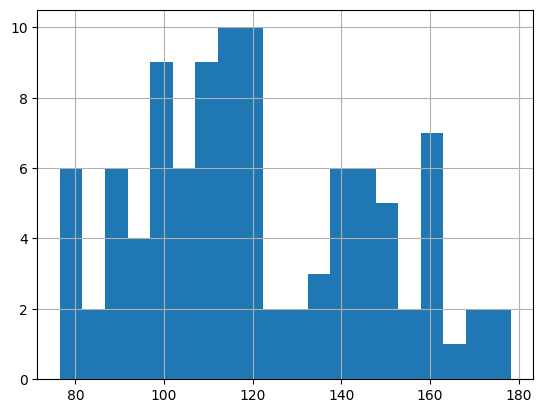

In [103]:
audio_features_100["tempo_bpm"].hist(bins=20)

In [104]:
audio_features_100[
    ["preview_file", "valence"]
].sort_values("valence")

,preview_file,valence
46,j_cole__4_your_eyez_only__1440924593.0.m4a,3.174302
72,j_cole__1985_intro_to_the_fall_off__1373861504...,3.547407
50,21_savage__3am_on_glenwood__1653012722.0.m4a,3.785471
61,j_cole__she_s_mine_pt_1__1440924585.0.m4a,3.954817
35,logic__44_more__1355219990.0.m4a,4.015415
...,...,...
80,glee_cast__i_ve_had_the_time_of_my_life__40192...,6.936751
9,amerie__1_thing__153437689.0.m4a,7.008817
93,ciara_featuring_missy_elliott__1_2_step__16740...,7.023382
74,fall_out_boy__dance_dance__1440749367.0.m4a,7.342772


In [106]:
audio_features_100[
    ["preview_file", "arousal"]
].sort_values("arousal")

,preview_file,arousal
61,j_cole__she_s_mine_pt_1__1440924585.0.m4a,3.742853
48,bon_jovi__you_want_to_make_a_memory__144082101...,4.233918
50,21_savage__3am_on_glenwood__1653012722.0.m4a,4.260291
4,morgan_wallen__skoal_chevy_and_browning__18021...,4.395068
94,olivia_rodrigo__1_step_forward_3_steps_back__1...,4.418778
...,...,...
51,chappell_roan__good_luck_babe__1737497080.0.m4a,6.509743
82,bizarrap_shakira__bzrp_music_sessions_vol_53__...,6.549721
76,train__hey_soul_sister__425320500.0.m4a,6.588519
56,justin_moore_priscilla_block__you_me_whiskey__...,6.648797


<Axes: >

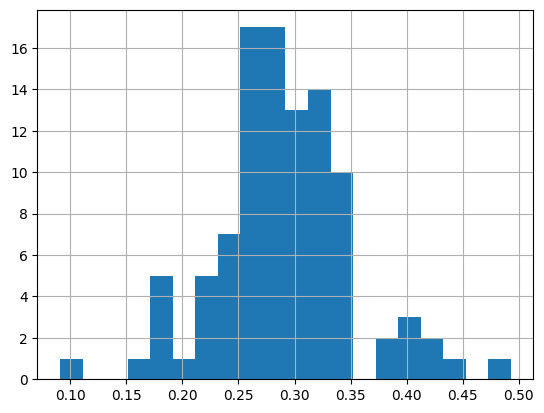

In [107]:
audio_features_100["rms_loudness"].hist(bins=20)

In [108]:
audio_features_100[
    ["preview_file", "spectral_centroid_mean"]
].sort_values("spectral_centroid_mean")

,preview_file,spectral_centroid_mean
61,j_cole__she_s_mine_pt_1__1440924585.0.m4a,1073.756332
46,j_cole__4_your_eyez_only__1440924593.0.m4a,1612.802000
70,taylor_swift__so_long_london__1742058083.0.m4a,1666.650614
17,taylor_swift__you_re_on_your_own_kid__16515164...,1717.242480
94,olivia_rodrigo__1_step_forward_3_steps_back__1...,1722.536017
...,...,...
58,jung_kook_jack_harlow__3d__1707603486.0.m4a,4492.084314
21,ariana_grande__yes_and__1724584103.0.m4a,4595.120665
49,ariana_grande_feat_doja_cat_megan_thee_stallio...,4680.721619
15,the_chainsmokers__selfie__1445876398.0.m4a,4999.653394


In [109]:
audio_features_100[genre_family_cols].mean().sort_values(
    ascending=False
)

genre_family_electronic                0.491403
genre_family_hip_hop                   0.487430
genre_family_rock                      0.429657
genre_family_pop                       0.253821
genre_family_funk__soul                0.107356
genre_family_folk_world_and_country    0.083718
genre_family_latin                     0.037136
genre_family_reggae                    0.029259
genre_family_blues                     0.016350
genre_family_non_music                 0.015589
genre_family_jazz                      0.014466
genre_family_stage_and_screen          0.008803
genre_family_classical                 0.004898
genre_family_children's                0.004631
genre_family_brass_and_military        0.001208
dtype: float32

### 5 and 50 song test w/ new feature extraction

In [116]:
test_results_clean = []

for file in test_files[1:6]:
    features = extract_audio_features(
        filename=str(file),
        labels=labels
    )
    test_results_clean.append(features)

test_clean_df = pd.DataFrame(test_results_clean)
test_clean_df.head()

,preview_filename,preview_duration_sec,tempo_bpm,beat_confidence,rms_loudness,mode,key_strength,spectral_centroid_mean,spectral_rolloff_mean,valence,...,genre_family_funk__soul,genre_family_hip_hop,genre_family_jazz,genre_family_latin,genre_family_non_music,genre_family_pop,genre_family_reggae,genre_family_rock,genre_family_stage_and_screen,audio_feature_error
0,preview_clips/plain_white_t_s__1_2_3_4__160588...,29.97551,89.632843,2.634862,0.260873,major,0.936624,2826.144464,1084.210111,5.436965,...,0.003454,0.029134,0.005265,0.010116,0.025339,0.083516,0.023637,1.199483,0.002437,None
1,preview_clips/dan_shay_justin_bieber__10_000_h...,29.92907,178.205811,2.696650,0.247301,major,0.937904,3112.863702,1233.468614,4.820089,...,0.214132,0.167848,0.007165,0.081251,0.026035,0.675385,0.016751,0.140071,0.005422,None
2,preview_clips/darryl_worley__awful_beautiful_l...,29.92907,112.451279,4.022439,0.248761,major,0.941523,2545.897491,1314.309934,6.257137,...,0.011747,0.001111,0.001728,0.000727,0.025739,0.228829,0.000909,0.723153,0.004464,None
3,preview_clips/ciara_featuring_missy_elliott__1...,29.92907,116.173401,2.469709,0.274486,major,0.508867,3324.488946,2381.004724,7.023382,...,0.123932,0.497635,0.000735,0.010825,0.000528,0.070866,0.003168,0.007899,0.000968,None
4,preview_clips/olivia_rodrigo__1_step_forward_3...,29.97551,172.265625,0.554861,0.185166,major,0.882782,1722.536017,776.578637,4.464632,...,0.155670,0.042945,0.100163,0.052241,0.014486,0.448652,0.005238,0.152280,0.011177,None


In [119]:
from pathlib import Path
import pandas as pd
from tqdm.notebook import tqdm

# Get available preview clips, excluding old manual test clip
preview_files = [
    f for f in Path("preview_clips").glob("*.m4a")
    if f.name != "test_preview.m4a"
]

preview_files = sorted(preview_files)[:50]

print("Number of files:", len(preview_files))
preview_files[:5]

Number of files: 50


[PosixPath('preview_clips/21_savage__3am_on_glenwood__1653012722.0.m4a'),
 PosixPath('preview_clips/akon__sorry_blame_it_on_me__1610800965.0.m4a'),
 PosixPath('preview_clips/amerie__1_thing__153437689.0.m4a'),
 PosixPath('preview_clips/andy_grammer__honey_i_m_good__1780516397.0.m4a'),
 PosixPath('preview_clips/ariana_grande__break_up_with_your_girlfriend_i_m_bored__1450334170.0.m4a')]

In [120]:
audio_results_50 = []

for file in tqdm(preview_files, total=len(preview_files)):
    features = extract_audio_features(
        filename=str(file),
        labels=labels
    )
    
    audio_results_50.append(features)

audio_features_50 = pd.DataFrame(audio_results_50)

audio_features_50.to_csv(
    "audio_features_50_clean_test.csv",
    index=False
)

audio_features_50.head()

  0%|          | 0/50 [00:00<?, ?it/s]

,preview_filename,preview_duration_sec,tempo_bpm,beat_confidence,rms_loudness,mode,key_strength,spectral_centroid_mean,spectral_rolloff_mean,valence,...,genre_family_funk__soul,genre_family_hip_hop,genre_family_jazz,genre_family_latin,genre_family_non_music,genre_family_pop,genre_family_reggae,genre_family_rock,genre_family_stage_and_screen,audio_feature_error
0,preview_clips/21_savage__3am_on_glenwood__1653...,29.92907,89.902718,2.435037,0.380565,minor,0.787219,1729.363810,741.743732,3.785471,...,0.053855,1.196558,0.001343,0.001611,0.001194,0.005218,0.006038,0.025959,0.000498,None
1,preview_clips/akon__sorry_blame_it_on_me__1610...,29.97551,88.166763,3.568150,0.306813,major,0.799940,3086.293058,1610.740260,5.732172,...,0.217244,1.212054,0.010134,0.016126,0.000750,0.009697,0.046731,0.006005,0.000626,None
2,preview_clips/amerie__1_thing__153437689.0.m4a,29.92907,99.942734,2.585076,0.281846,minor,0.669555,4282.233563,3431.975268,7.008817,...,0.881994,0.575293,0.046630,0.057235,0.001304,0.095674,0.044980,0.051962,0.013965,None
3,preview_clips/andy_grammer__honey_i_m_good__17...,29.97551,121.938454,3.431594,0.261432,major,0.853967,3627.470155,1547.957306,6.019595,...,0.199591,0.121519,0.083876,0.011575,0.003668,0.093614,0.039674,0.057061,0.003933,None
4,preview_clips/ariana_grande__break_up_with_you...,29.97551,84.889038,3.078643,0.327433,minor,0.884141,3362.750300,1035.960402,5.133042,...,0.065846,0.582848,0.000398,0.294080,0.000309,0.102198,0.003993,0.005926,0.000476,None


In [122]:
audio_features_50.shape

(50, 37)

In [123]:
audio_features_50["audio_feature_error"].value_counts(dropna=False)

audio_feature_error
None    50
Name: count, dtype: int64

In [124]:
audio_features_50.describe()

,preview_duration_sec,tempo_bpm,beat_confidence,rms_loudness,key_strength,spectral_centroid_mean,spectral_rolloff_mean,valence,arousal,genre_1_score,...,genre_family_folk_world_and_country,genre_family_funk__soul,genre_family_hip_hop,genre_family_jazz,genre_family_latin,genre_family_non_music,genre_family_pop,genre_family_reggae,genre_family_rock,genre_family_stage_and_screen
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,...,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,29.951361,117.297032,2.941566,0.290404,0.847237,3114.244539,1506.339426,5.667453,5.507128,0.332644,...,0.075626,0.141122,0.480731,0.015783,0.042884,0.016215,0.285932,0.020429,0.407635,0.007146
std,0.023437,26.528711,0.837436,0.052089,0.120884,748.397327,614.808005,0.969920,0.616475,0.181516,...,0.167553,0.195934,0.609149,0.030581,0.080143,0.026890,0.314394,0.024204,0.596743,0.008620
min,29.929070,76.503914,0.272895,0.164284,0.409320,1073.756332,386.763036,3.174302,3.742853,0.077609,...,0.000264,0.000647,0.001111,0.000049,0.000727,0.000076,0.001076,0.000909,0.001035,0.000045
25%,29.929070,97.711823,2.532902,0.261106,0.840521,2749.105302,1037.239561,5.097557,5.145393,0.210143,...,0.003623,0.023120,0.025671,0.001268,0.006856,0.000804,0.047500,0.007121,0.012811,0.001402
50%,29.929070,113.623291,3.009686,0.285033,0.885613,3118.147266,1454.118907,5.725917,5.474500,0.309250,...,0.016475,0.069111,0.146820,0.002902,0.020339,0.004147,0.159416,0.011852,0.062647,0.003763
75%,29.975510,133.078007,3.564060,0.321931,0.913937,3570.895078,1844.110193,6.398115,5.961446,0.420265,...,0.075708,0.180436,0.858667,0.015906,0.046271,0.024972,0.467434,0.025645,0.655568,0.008748
max,29.975510,178.205811,4.278076,0.429037,0.986526,4680.721619,3431.975268,7.553596,6.648797,0.936707,...,1.104487,0.881994,2.060127,0.165617,0.495896,0.158709,1.434788,0.141044,2.071413,0.033377


In [125]:
audio_features_50[
    [
        "preview_filename",
        "tempo_bpm",
        "beat_confidence",
        "rms_loudness",
        "mode",
        "key_strength",
        "spectral_centroid_mean",
        "spectral_rolloff_mean",
        "valence",
        "arousal",
        "genre_1",
        "genre_1_score"
    ]
].head(50)

,preview_filename,tempo_bpm,beat_confidence,rms_loudness,mode,key_strength,spectral_centroid_mean,spectral_rolloff_mean,valence,arousal,genre_1,genre_1_score
0,preview_clips/21_savage__3am_on_glenwood__1653...,89.902718,2.435037,0.380565,minor,0.787219,1729.363810,741.743732,3.785471,4.260291,Hip Hop---Cloud Rap,0.309495
1,preview_clips/akon__sorry_blame_it_on_me__1610...,88.166763,3.568150,0.306813,major,0.799940,3086.293058,1610.740260,5.732172,5.974985,Hip Hop---Conscious,0.185741
2,preview_clips/amerie__1_thing__153437689.0.m4a,99.942734,2.585076,0.281846,minor,0.669555,4282.233563,3431.975268,7.008817,5.272458,Hip Hop---RnB/Swing,0.261550
3,preview_clips/andy_grammer__honey_i_m_good__17...,121.938454,3.431594,0.261432,major,0.853967,3627.470155,1547.957306,6.019595,6.487543,Electronic---House,0.369195
4,preview_clips/ariana_grande__break_up_with_you...,84.889038,3.078643,0.327433,minor,0.884141,3362.750300,1035.960402,5.133042,4.923633,Hip Hop---Trap,0.428674
5,preview_clips/ariana_grande__thank_u_next__145...,107.147888,3.786348,0.287267,major,0.788653,2732.343404,854.361500,5.719663,5.472998,Funk / Soul---Contemporary R&B,0.155984
6,preview_clips/ariana_grande__yes_and__17245841...,119.016960,2.957922,0.345711,minor,0.848055,4595.120665,2532.818018,6.580185,6.333960,Pop---K-pop,0.312757
7,preview_clips/ariana_grande_feat_doja_cat_mega...,110.265793,3.236793,0.215394,major,0.881461,4680.721619,2508.968162,5.687089,6.184940,Pop---K-pop,0.570706
8,preview_clips/beyonce__16_carriages__173040858...,95.445480,0.506133,0.259759,major,0.921777,2891.238180,1282.475578,5.085895,5.549473,Funk / Soul---Contemporary R&B,0.227124
9,preview_clips/billy_ray_cyrus_with_miley_cyrus...,153.797577,2.425152,0.300458,major,0.932745,3711.417743,1251.997184,6.236165,5.507511,Rock---Pop Rock,0.288668


In [126]:
audio_features_50[
    ["preview_filename", "tempo_bpm"]
].sample(20, random_state=42)

,preview_filename,tempo_bpm
13,preview_clips/bruno_mars__24k_magic__116150402...,106.939056
39,preview_clips/j_cole__4_your_eyez_only__144092...,77.655853
30,preview_clips/glee_cast__hey_soul_sister__4343...,96.968185
45,preview_clips/jung_kook_jack_harlow__3d__17076...,107.830109
17,preview_clips/cody_johnson__til_you_can_t__158...,80.652222
48,preview_clips/keith_urban__john_cougar_john_de...,172.265549
26,preview_clips/fall_out_boy__dance_dance__14407...,114.439392
25,preview_clips/eminem__3am__1440738087.0.m4a,76.503914
32,preview_clips/gloriana__kissed_you_good_night_...,119.002380
19,preview_clips/darryl_worley__awful_beautiful_l...,112.451279


In [127]:
audio_features_50[
    ["preview_filename",
     "tempo_bpm",
     "beat_confidence"]
].sort_values("beat_confidence")

,preview_filename,tempo_bpm,beat_confidence
40,preview_clips/j_cole__she_s_mine_pt_1__1440924...,178.205811,0.272895
8,preview_clips/beyonce__16_carriages__173040858...,95.445480,0.506133
33,preview_clips/gracie_abrams__i_love_you_i_m_so...,115.500946,1.703919
22,preview_clips/dem_franchize_boyz_featuring_lil...,151.904007,1.825838
14,preview_clips/carrie_underwood__jesus_take_the...,152.234039,1.856424
23,preview_clips/drake__0_to_100_the_catch_up__14...,90.032822,1.858657
39,preview_clips/j_cole__4_your_eyez_only__144092...,77.655853,1.884257
27,preview_clips/fall_out_boy__sugar_we_re_goin_d...,162.343796,2.339203
9,preview_clips/billy_ray_cyrus_with_miley_cyrus...,153.797577,2.425152
0,preview_clips/21_savage__3am_on_glenwood__1653...,89.902718,2.435037


In [128]:
audio_features_50[
    ["preview_filename", "tempo_bpm"]
].sort_values("tempo_bpm", ascending=False)

,preview_filename,tempo_bpm
40,preview_clips/j_cole__she_s_mine_pt_1__1440924...,178.205811
18,preview_clips/dan_shay_justin_bieber__10_000_h...,178.205811
48,preview_clips/keith_urban__john_cougar_john_de...,172.265549
27,preview_clips/fall_out_boy__sugar_we_re_goin_d...,162.343796
9,preview_clips/billy_ray_cyrus_with_miley_cyrus...,153.797577
14,preview_clips/carrie_underwood__jesus_take_the...,152.234039
22,preview_clips/dem_franchize_boyz_featuring_lil...,151.904007
11,preview_clips/bon_jovi__you_want_to_make_a_mem...,148.000412
49,preview_clips/kelly_clarkson_ariana_grande__sa...,146.077667
20,preview_clips/david_guetta_featuring_justin_bi...,144.528259


In [129]:
audio_features_50[
    ["tempo_bpm", "arousal"]
].corr()

,tempo_bpm,arousal
tempo_bpm,1.000000,0.024193
arousal,0.024193,1.000000


In [130]:
audio_features_50[
    ["tempo_bpm", "rms_loudness"]
].corr()

,tempo_bpm,rms_loudness
tempo_bpm,1.000000,-0.098704
rms_loudness,-0.098704,1.000000


In [131]:
audio_features_50[
    ["preview_filename", "tempo_bpm"]
].sort_values("tempo_bpm")

,preview_filename,tempo_bpm
25,preview_clips/eminem__3am__1440738087.0.m4a,76.503914
39,preview_clips/j_cole__4_your_eyez_only__144092...,77.655853
34,preview_clips/green_day__21_guns__315611467.0.m4a,79.562775
17,preview_clips/cody_johnson__til_you_can_t__158...,80.652222
4,preview_clips/ariana_grande__break_up_with_you...,84.889038
1,preview_clips/akon__sorry_blame_it_on_me__1610...,88.166763
43,preview_clips/jay_z__4_44__1440935736.0.m4a,89.443672
0,preview_clips/21_savage__3am_on_glenwood__1653...,89.902718
23,preview_clips/drake__0_to_100_the_catch_up__14...,90.032822
21,preview_clips/daya__sit_still_look_pretty__174...,90.979836


In [132]:
import numpy as np
import pandas as pd

def adjust_tempo_with_genre(row):
    bpm = row["tempo_bpm"]
    
    hiphop = row.get("genre_family_hip_hop", 0)
    country = row.get("genre_family_folk_world_and_country", 0)
    pop = row.get("genre_family_pop", 0)
    rock = row.get("genre_family_rock", 0)
    electronic = row.get("genre_family_electronic", 0)

    adjusted = bpm
    reason = "unchanged"

    # Strong likely double-time cases
    if bpm >= 165 and (hiphop >= 0.25 or country >= 0.10 or pop >= 0.20):
        adjusted = bpm / 2
        reason = "halved_high_bpm_pop_hiphop_country"

    # Moderate high BPM, likely double-time for non-electronic/non-rock songs
    elif bpm >= 150 and electronic < 0.50 and rock < 0.50:
        adjusted = bpm / 2
        reason = "halved_high_bpm_non_electronic_non_rock"

    # Very low BPM may be half-time if song has strong electronic/hiphop/pop energy
    elif bpm < 80 and (electronic >= 0.40 or hiphop >= 0.40 or pop >= 0.30):
        adjusted = bpm * 2
        reason = "doubled_low_bpm_pop_hiphop_electronic"

    return pd.Series({
        "tempo_adjusted": adjusted,
        "tempo_adjustment_reason": reason
    })


tempo_adjustments_50 = audio_features_50.apply(
    adjust_tempo_with_genre,
    axis=1
)

audio_features_50_test = pd.concat(
    [audio_features_50, tempo_adjustments_50],
    axis=1
)

audio_features_50_test[
    [
        "preview_filename",
        "tempo_bpm",
        "tempo_adjusted",
        "tempo_adjustment_reason",
        "genre_1",
        "genre_family_pop",
        "genre_family_hip_hop",
        "genre_family_electronic",
        "genre_family_rock",
        "genre_family_folk_world_and_country"
    ]
].sort_values("tempo_bpm", ascending=False).head(25)

,preview_filename,tempo_bpm,tempo_adjusted,tempo_adjustment_reason,genre_1,genre_family_pop,genre_family_hip_hop,genre_family_electronic,genre_family_rock,genre_family_folk_world_and_country
40,preview_clips/j_cole__she_s_mine_pt_1__1440924...,178.205811,89.102905,halved_high_bpm_pop_hiphop_country,Electronic---Downtempo,0.151265,0.215563,0.502691,0.301756,0.245527
18,preview_clips/dan_shay_justin_bieber__10_000_h...,178.205811,89.102905,halved_high_bpm_pop_hiphop_country,Electronic---Disco Polo,0.675385,0.167848,0.850812,0.140071,0.076713
48,preview_clips/keith_urban__john_cougar_john_de...,172.265549,86.132774,halved_high_bpm_pop_hiphop_country,Hip Hop---Pop Rap,0.207820,0.529184,0.608809,0.505004,0.072694
27,preview_clips/fall_out_boy__sugar_we_re_goin_d...,162.343796,162.343796,unchanged,Rock---Alternative Rock,0.083464,0.016414,0.052181,1.861341,0.036356
9,preview_clips/billy_ray_cyrus_with_miley_cyrus...,153.797577,153.797577,unchanged,Rock---Pop Rock,0.836323,0.024774,0.086885,1.140563,0.133087
14,preview_clips/carrie_underwood__jesus_take_the...,152.234039,76.117020,halved_high_bpm_non_electronic_non_rock,Pop---Ballad,0.576086,0.023272,0.111763,0.363554,0.327468
22,preview_clips/dem_franchize_boyz_featuring_lil...,151.904007,75.952003,halved_high_bpm_non_electronic_non_rock,Hip Hop---Crunk,0.001076,1.708320,0.025867,0.001035,0.000527
11,preview_clips/bon_jovi__you_want_to_make_a_mem...,148.000412,148.000412,unchanged,Rock---Alternative Rock,0.232106,0.025048,0.247907,0.889258,0.241480
49,preview_clips/kelly_clarkson_ariana_grande__sa...,146.077667,146.077667,unchanged,Pop---K-pop,0.954257,0.041888,0.382178,0.210281,0.051531
20,preview_clips/david_guetta_featuring_justin_bi...,144.528259,144.528259,unchanged,Electronic---Hands Up,0.167568,0.132397,1.817552,0.019275,0.009464


In [133]:
def adjust_tempo_with_rules(row):
    bpm = row["tempo_bpm"]

    hiphop = row.get("genre_family_hip_hop", 0)
    country = row.get("genre_family_folk_world_and_country", 0)
    pop = row.get("genre_family_pop", 0)
    rock = row.get("genre_family_rock", 0)
    electronic = row.get("genre_family_electronic", 0)

    adjusted = bpm
    reason = "unchanged"

    # Most Billboard pop/rock/country/hip-hop above 145 is often double-time
    if 145 <= bpm <= 180:
        adjusted = bpm / 2
        reason = "halved_145_to_180_likely_double_time"

    # Keep very high electronic tracks as-is only if strongly electronic
    if bpm >= 150 and electronic >= 1.0 and hiphop < 0.25 and country < 0.10:
        adjusted = bpm
        reason = "kept_high_bpm_strong_electronic"

    # Very low BPM may be half-time if it has strong pop/electronic/hip-hop signal
    if bpm < 75 and (electronic >= 0.5 or hiphop >= 0.5 or pop >= 0.5):
        adjusted = bpm * 2
        reason = "doubled_low_bpm_likely_half_time"

    return pd.Series({
        "tempo_bpm_adjusted": adjusted,
        "tempo_adjustment_reason": reason
    })

In [134]:
tempo_adjustments_50_v2 = audio_features_50.apply(
    adjust_tempo_with_rules,
    axis=1
)

audio_features_50_tempo_v2 = pd.concat(
    [audio_features_50, tempo_adjustments_50_v2],
    axis=1
)

audio_features_50_tempo_v2[
    [
        "preview_filename",
        "tempo_bpm",
        "tempo_bpm_adjusted",
        "tempo_adjustment_reason",
        "genre_1",
        "genre_family_pop",
        "genre_family_hip_hop",
        "genre_family_electronic",
        "genre_family_rock",
        "genre_family_folk_world_and_country"
    ]
].sort_values("tempo_bpm", ascending=False).head(30)

,preview_filename,tempo_bpm,tempo_bpm_adjusted,tempo_adjustment_reason,genre_1,genre_family_pop,genre_family_hip_hop,genre_family_electronic,genre_family_rock,genre_family_folk_world_and_country
40,preview_clips/j_cole__she_s_mine_pt_1__1440924...,178.205811,89.102905,halved_145_to_180_likely_double_time,Electronic---Downtempo,0.151265,0.215563,0.502691,0.301756,0.245527
18,preview_clips/dan_shay_justin_bieber__10_000_h...,178.205811,89.102905,halved_145_to_180_likely_double_time,Electronic---Disco Polo,0.675385,0.167848,0.850812,0.140071,0.076713
48,preview_clips/keith_urban__john_cougar_john_de...,172.265549,86.132774,halved_145_to_180_likely_double_time,Hip Hop---Pop Rap,0.207820,0.529184,0.608809,0.505004,0.072694
27,preview_clips/fall_out_boy__sugar_we_re_goin_d...,162.343796,81.171898,halved_145_to_180_likely_double_time,Rock---Alternative Rock,0.083464,0.016414,0.052181,1.861341,0.036356
9,preview_clips/billy_ray_cyrus_with_miley_cyrus...,153.797577,76.898788,halved_145_to_180_likely_double_time,Rock---Pop Rock,0.836323,0.024774,0.086885,1.140563,0.133087
14,preview_clips/carrie_underwood__jesus_take_the...,152.234039,76.117020,halved_145_to_180_likely_double_time,Pop---Ballad,0.576086,0.023272,0.111763,0.363554,0.327468
22,preview_clips/dem_franchize_boyz_featuring_lil...,151.904007,75.952003,halved_145_to_180_likely_double_time,Hip Hop---Crunk,0.001076,1.708320,0.025867,0.001035,0.000527
11,preview_clips/bon_jovi__you_want_to_make_a_mem...,148.000412,74.000206,halved_145_to_180_likely_double_time,Rock---Alternative Rock,0.232106,0.025048,0.247907,0.889258,0.241480
49,preview_clips/kelly_clarkson_ariana_grande__sa...,146.077667,73.038834,halved_145_to_180_likely_double_time,Pop---K-pop,0.954257,0.041888,0.382178,0.210281,0.051531
20,preview_clips/david_guetta_featuring_justin_bi...,144.528259,144.528259,unchanged,Electronic---Hands Up,0.167568,0.132397,1.817552,0.019275,0.009464


In [135]:
genre_family_cols = [
    c for c in audio_features_50.columns
    if c.startswith("genre_family_")
]

audio_features_50[genre_family_cols].describe()

,genre_family_blues,genre_family_brass_and_military,genre_family_children's,genre_family_classical,genre_family_electronic,genre_family_folk_world_and_country,genre_family_funk__soul,genre_family_hip_hop,genre_family_jazz,genre_family_latin,genre_family_non_music,genre_family_pop,genre_family_reggae,genre_family_rock,genre_family_stage_and_screen
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,0.015607,0.000552,0.004705,0.002299,0.479654,0.075626,0.141122,0.480731,0.015783,0.042884,0.016215,0.285932,0.020429,0.407635,0.007146
std,0.039656,0.002159,0.012175,0.006774,0.517703,0.167553,0.195934,0.609149,0.030581,0.080143,0.026890,0.314394,0.024204,0.596743,0.008620
min,0.000033,0.000001,0.000004,0.000004,0.010123,0.000264,0.000647,0.001111,0.000049,0.000727,0.000076,0.001076,0.000909,0.001035,0.000045
25%,0.000562,0.000010,0.000095,0.000041,0.089350,0.003623,0.023120,0.025671,0.001268,0.006856,0.000804,0.047500,0.007121,0.012811,0.001402
50%,0.001601,0.000062,0.000610,0.000357,0.300095,0.016475,0.069111,0.146820,0.002902,0.020339,0.004147,0.159416,0.011852,0.062647,0.003763
75%,0.006437,0.000247,0.002361,0.001387,0.628090,0.075708,0.180436,0.858667,0.015906,0.046271,0.024972,0.467434,0.025645,0.655568,0.008748
max,0.200416,0.014869,0.065421,0.043655,2.088780,1.104487,0.881994,2.060127,0.165617,0.495896,0.158709,1.434788,0.141044,2.071413,0.033377


In [136]:
audio_features_50[
    ["preview_filename"] + genre_family_cols
].sample(20, random_state=42)

,preview_filename,genre_family_blues,genre_family_brass_and_military,genre_family_children's,genre_family_classical,genre_family_electronic,genre_family_folk_world_and_country,genre_family_funk__soul,genre_family_hip_hop,genre_family_jazz,genre_family_latin,genre_family_non_music,genre_family_pop,genre_family_reggae,genre_family_rock,genre_family_stage_and_screen
13,preview_clips/bruno_mars__24k_magic__116150402...,0.000130,0.000020,0.000975,0.000034,0.299665,0.003235,0.863043,0.950606,0.001663,0.005355,0.002474,0.068830,0.010995,0.010661,0.001383
39,preview_clips/j_cole__4_your_eyez_only__144092...,0.001159,0.000008,0.000031,0.000016,0.096744,0.009429,0.147949,1.769476,0.011445,0.002140,0.003631,0.020741,0.007994,0.006243,0.001668
30,preview_clips/glee_cast__hey_soul_sister__4343...,0.005467,0.000577,0.007177,0.000432,0.358571,0.066025,0.065868,0.094790,0.028318,0.062448,0.011219,0.371573,0.141044,0.664427,0.003747
45,preview_clips/jung_kook_jack_harlow__3d__17076...,0.000912,0.000062,0.002393,0.000046,0.634518,0.005594,0.124684,0.496895,0.004743,0.021994,0.008778,0.595632,0.041927,0.035790,0.002945
17,preview_clips/cody_johnson__til_you_can_t__158...,0.012132,0.000189,0.000253,0.000460,0.066666,0.178056,0.014257,0.011787,0.001243,0.057288,0.049486,0.150218,0.004950,1.198153,0.002156
48,preview_clips/keith_urban__john_cougar_john_de...,0.006647,0.000267,0.001358,0.001391,0.608809,0.072694,0.219945,0.529184,0.024875,0.076241,0.018702,0.207820,0.031112,0.505004,0.024274
26,preview_clips/fall_out_boy__dance_dance__14407...,0.002049,0.000067,0.000242,0.002686,0.023571,0.031725,0.000647,0.004545,0.002475,0.001781,0.008855,0.010208,0.004726,2.013344,0.002708
25,preview_clips/eminem__3am__1440738087.0.m4a,0.001120,0.000168,0.000075,0.000039,0.111232,0.005526,0.105077,1.131481,0.002878,0.011416,0.003461,0.017543,0.024063,0.032819,0.003594
32,preview_clips/gloriana__kissed_you_good_night_...,0.083568,0.000460,0.001025,0.001625,0.049899,0.089529,0.028011,0.009299,0.026452,0.125661,0.007281,0.105464,0.014295,1.069929,0.007369
19,preview_clips/darryl_worley__awful_beautiful_l...,0.081906,0.000175,0.001720,0.000675,0.010123,1.104487,0.011747,0.001111,0.001728,0.000727,0.025739,0.228829,0.000909,0.723153,0.004464


# SECTION 08 — Inspect Returned Features

In [ ]:
pd.Series(features).sort_index()

# SECTION 09 — Build Audio Feature Dataset

In [ ]:
audio_results = []

In [ ]:
for song in ...

## Download

In [139]:
from pathlib import Path
import pandas as pd
from tqdm.notebook import tqdm
import time

preview_files = [
    f for f in Path("preview_clips").glob("*.m4a")
    if f.name != "test_preview.m4a"
]

preview_files = sorted(preview_files)

print("Files to process:", len(preview_files))

Files to process: 100


In [ ]:
from pathlib import Path
import pandas as pd
import time
from tqdm.notebook import tqdm

PREVIEW_DIR = Path("preview_clips")
PREVIEW_DIR.mkdir(exist_ok=True)

download_results = []
total = len(usable_apple_df)

start = time.time()

for i, (idx, row) in enumerate(
    tqdm(usable_apple_df.iterrows(), total=total),
    start=1
):
    preview_file, download_status = download_preview(row)

    download_results.append({
        "index": idx,
        "search_song": row.get("search_song"),
        "search_artist": row.get("search_artist"),
        "apple_track_id": row.get("apple_track_id"),
        "preview_file": preview_file,
        "download_status": download_status
    })

    # checkpoint + status every 100 songs
    if i % 100 == 0:
        checkpoint_df = pd.DataFrame(download_results)
        checkpoint_df.to_csv("preview_download_checkpoint.csv", index=False)

        elapsed = time.time() - start
        rate = i / elapsed
        remaining = total - i
        eta_min = remaining / rate / 60

        print(
            f"Downloaded/checkpointed {i}/{total} "
            f"({i/total:.1%}) | "
            f"Rate: {rate:.2f} songs/sec | "
            f"ETA: {eta_min:.1f} min"
        )

    time.sleep(0.05)

download_df = pd.DataFrame(download_results)
download_df.to_csv("preview_download_results.csv", index=False)

usable_apple_with_files = usable_apple_df.reset_index().merge(
    download_df,
    on="index",
    how="left"
)

usable_apple_with_files.to_csv(
    "usable_apple_matches_with_files.csv",
    index=False
)

print("Done downloading.")
print(download_df["download_status"].value_counts(dropna=False))

In [152]:
download_results = []

total = len(usable_apple_df)
start = time.time()

for i, (idx, row) in enumerate(
    tqdm(usable_apple_df.iterrows(), total=total),
    start=1
):
    preview_file, download_status = download_preview(row)

    download_results.append({
        "index": idx,
        "search_song": row.get("search_song"),
        "search_artist": row.get("search_artist"),
        "apple_track_id": row.get("apple_track_id"),
        "preview_file": preview_file,
        "download_status": download_status
    })

    # Save checkpoint every 100 songs
    if i % 100 == 0:
        checkpoint_df = pd.DataFrame(download_results)
        checkpoint_df.to_csv("preview_download_checkpoint.csv", index=False)

        elapsed = time.time() - start
        rate = i / elapsed
        remaining = total - i
        eta_min = remaining / rate / 60

        print(
            f"Downloaded/checkpointed {i}/{total} "
            f"({i / total:.1%}) | "
            f"Rate: {rate:.2f} songs/sec | "
            f"ETA: {eta_min:.1f} min"
        )

    # Gentle pause so we don't hammer Apple preview URLs
    time.sleep(0.05)

download_df = pd.DataFrame(download_results)

download_df.to_csv(
    "preview_download_results.csv",
    index=False
)

usable_apple_with_files = usable_apple_df.reset_index().merge(
    download_df,
    on="index",
    how="left"
)

usable_apple_with_files.to_csv(
    "usable_apple_matches_with_files.csv",
    index=False
)

print("Done downloading.")
print(download_df["download_status"].value_counts(dropna=False))
print("Usable with files:", usable_apple_with_files["preview_file"].notna().mean())

  0%|          | 0/3783 [00:00<?, ?it/s]

Downloaded/checkpointed 100/3783 (2.6%) | Rate: 18.01 songs/sec | ETA: 3.4 min
Downloaded/checkpointed 200/3783 (5.3%) | Rate: 6.18 songs/sec | ETA: 9.7 min
Downloaded/checkpointed 300/3783 (7.9%) | Rate: 4.99 songs/sec | ETA: 11.6 min
Downloaded/checkpointed 400/3783 (10.6%) | Rate: 4.58 songs/sec | ETA: 12.3 min
Downloaded/checkpointed 500/3783 (13.2%) | Rate: 4.29 songs/sec | ETA: 12.7 min
Downloaded/checkpointed 600/3783 (15.9%) | Rate: 4.08 songs/sec | ETA: 13.0 min
Downloaded/checkpointed 700/3783 (18.5%) | Rate: 3.95 songs/sec | ETA: 13.0 min
Downloaded/checkpointed 800/3783 (21.1%) | Rate: 3.85 songs/sec | ETA: 12.9 min
Downloaded/checkpointed 900/3783 (23.8%) | Rate: 3.71 songs/sec | ETA: 12.9 min
Downloaded/checkpointed 1000/3783 (26.4%) | Rate: 3.62 songs/sec | ETA: 12.8 min
Downloaded/checkpointed 1100/3783 (29.1%) | Rate: 3.56 songs/sec | ETA: 12.6 min
Downloaded/checkpointed 1200/3783 (31.7%) | Rate: 3.46 songs/sec | ETA: 12.4 min
Downloaded/checkpointed 1300/3783 (34.4%)

In [153]:
download_df["download_status"].value_counts(dropna=False)

download_status
downloaded           3682
already_exists        100
error_ReadTimeout       1
Name: count, dtype: int64

In [156]:
usable_apple_with_files[
    [
        "search_song_x",
        "search_song_y",
        "search_artist_x",
        "search_artist_y"
    ]
].head()

,search_song_x,search_song_y,search_artist_x,search_artist_y
0,"""1 Step Forward, 3 Steps Back""","""1 Step Forward, 3 Steps Back""",Olivia Rodrigo,Olivia Rodrigo
1,"""1, 2 Step""","""1, 2 Step""",Ciara Featuring Missy Elliott,Ciara Featuring Missy Elliott
2,"""1, 2, 3, 4""","""1, 2, 3, 4""",Plain White T's,Plain White T's
3,"""10,000 Hours""","""10,000 Hours""",Dan + Shay & Justin Bieber,Dan + Shay & Justin Bieber
4,"""Awful, Beautiful Life""","""Awful, Beautiful Life""",Darryl Worley,Darryl Worley


In [157]:
features["apple_track_id"] = getattr(row, "apple_track_id_x", None)

features["search_song"] = getattr(
    row,
    "search_song_x",
    None
)

features["search_artist"] = getattr(
    row,
    "search_artist_x",
    None
)

### Fix failed download

In [162]:
# Get the failed row(s)
failed_rows = usable_apple_with_files[
    usable_apple_with_files["preview_file"].isna()
].copy()

failed_rows[
    ["search_song_x", "search_artist_x", "preview_url", "download_status"]
]

,search_song_x,search_artist_x,preview_url,download_status
3231,The Remorse,Drake,https://audio-ssl.itunes.apple.com/itunes-asse...,error_ReadTimeout


In [164]:
# Get the one failed row
idx = usable_apple_with_files[
    usable_apple_with_files["preview_file"].isna()
].index[0]

row = usable_apple_with_files.loc[idx]

print(row["search_song_x"], "-", row["search_artist_x"])
print(row["preview_url"])

The Remorse - Drake
https://audio-ssl.itunes.apple.com/itunes-assets/AudioPreview125/v4/b7/ac/0e/b7ac0e58-89f5-a1cf-840d-80a5a8021030/mzaf_16500916507592324009.plus.aac.p.m4a


In [165]:
# Manually create the columns that download_preview expects
row_for_download = row.copy()
row_for_download["search_song"] = row["search_song_x"]
row_for_download["search_artist"] = row["search_artist_x"]
row_for_download["apple_track_id"] = row["apple_track_id_x"]

preview_file, download_status = download_preview(row_for_download)

print(preview_file)
print(download_status)

preview_clips/drake__the_remorse__1584449542.0.m4a
downloaded


In [166]:
# Add the result back into usable_apple_with_files
usable_apple_with_files.loc[idx, "preview_file"] = preview_file
usable_apple_with_files.loc[idx, "download_status"] = download_status

usable_apple_with_files.to_csv(
    "usable_apple_matches_with_files.csv",
    index=False
)

usable_apple_with_files.loc[
    idx,
    ["search_song_x", "search_artist_x", "preview_file", "download_status"]
]

search_song_x                                            The Remorse
search_artist_x                                                Drake
preview_file       preview_clips/drake__the_remorse__1584449542.0...
download_status                                           downloaded
Name: 3231, dtype: object

## Extract Audio features w/ checkpoints and status

In [167]:
## Extract Audio Features w/ checkpoints and status

valid_files_df = usable_apple_with_files[
    usable_apple_with_files["preview_file"].notna()
].copy()

valid_files_df = valid_files_df.reset_index(drop=True)

print("Files to extract:", len(valid_files_df))

Files to extract: 3783


In [168]:
audio_results = []

total = len(valid_files_df)
start = time.time()

for i, row in enumerate(
    tqdm(valid_files_df.itertuples(index=False), total=total),
    start=1
):
    features = extract_audio_features(
        filename=row.preview_file,
        labels=labels
    )

    # Add identifiers so we can merge later
    features["apple_track_id"] = getattr(row, "apple_track_id_x", None)
    features["search_song"] = getattr(row, "search_song_x", None)
    features["search_artist"] = getattr(row, "search_artist_x", None)
    features["preview_file"] = row.preview_file

    audio_results.append(features)

    # Save checkpoint every 100 songs
    if i % 100 == 0:
        checkpoint_df = pd.DataFrame(audio_results)

        checkpoint_df.to_csv(
            "audio_features_checkpoint.csv",
            index=False
        )

        elapsed = time.time() - start
        rate = i / elapsed
        remaining = total - i
        eta_min = remaining / rate / 60

        errors = checkpoint_df["audio_feature_error"].notna().sum()

        print(
            f"Extracted/checkpointed {i}/{total} "
            f"({i / total:.1%}) | "
            f"Rate: {rate:.2f} songs/sec | "
            f"ETA: {eta_min:.1f} min | "
            f"Errors: {errors}"
        )

audio_features_full = pd.DataFrame(audio_results)

audio_features_full.to_csv(
    "audio_features_full.csv",
    index=False
)

print("Done extracting.")
print("Shape:", audio_features_full.shape)
print(audio_features_full["audio_feature_error"].value_counts(dropna=False))

  0%|          | 0/3783 [00:00<?, ?it/s]

Extracted/checkpointed 100/3783 (2.6%) | Rate: 0.71 songs/sec | ETA: 86.9 min | Errors: 0
Extracted/checkpointed 200/3783 (5.3%) | Rate: 0.70 songs/sec | ETA: 85.0 min | Errors: 0
Extracted/checkpointed 300/3783 (7.9%) | Rate: 0.69 songs/sec | ETA: 83.8 min | Errors: 0
Extracted/checkpointed 400/3783 (10.6%) | Rate: 0.68 songs/sec | ETA: 82.4 min | Errors: 0
Extracted/checkpointed 500/3783 (13.2%) | Rate: 0.68 songs/sec | ETA: 80.5 min | Errors: 0
Extracted/checkpointed 600/3783 (15.9%) | Rate: 0.68 songs/sec | ETA: 78.3 min | Errors: 0
Extracted/checkpointed 700/3783 (18.5%) | Rate: 0.68 songs/sec | ETA: 75.9 min | Errors: 0
Extracted/checkpointed 800/3783 (21.1%) | Rate: 0.68 songs/sec | ETA: 73.3 min | Errors: 0
Extracted/checkpointed 900/3783 (23.8%) | Rate: 0.68 songs/sec | ETA: 70.7 min | Errors: 0
Extracted/checkpointed 1000/3783 (26.4%) | Rate: 0.68 songs/sec | ETA: 68.2 min | Errors: 0
Extracted/checkpointed 1100/3783 (29.1%) | Rate: 0.68 songs/sec | ETA: 65.5 min | Errors: 0


## Tempo adjustment

In [169]:
tempo_adjustments = audio_features_full.apply(
    adjust_tempo_final,
    axis=1
)

audio_features_full = pd.concat(
    [audio_features_full, tempo_adjustments],
    axis=1
)

audio_features_full.to_csv(
    "audio_features_full_with_tempo_adjusted.csv",
    index=False
)

audio_features_full[
    ["tempo_bpm_raw", "tempo_bpm_adjusted"]
].describe()

,tempo_bpm_raw,tempo_bpm_adjusted
count,3783.000000,3783.000000
mean,117.251375,108.876222
std,25.369502,23.781746
min,59.921703,59.921703
25%,95.329132,88.773232
50%,117.921303,106.933563
75%,136.425705,128.058739
max,184.570312,178.205811


In [170]:
audio_features_full["tempo_adjustment_reason"].value_counts()

tempo_adjustment_reason
unchanged                                  3191
halved_145_180_likely_double_time           398
kept_high_bpm_strong_electronic_or_rock     187
halved_over_180_extreme_bpm                   7
Name: count, dtype: int64

In [171]:
audio_features_full[
    audio_features_full["tempo_adjustment_reason"] != "unchanged"
][
    [
        "preview_filename",
        "tempo_bpm_raw",
        "tempo_bpm_adjusted",
        "tempo_adjustment_reason",
        "genre_1",
        "genre_family_electronic",
        "genre_family_rock",
        "genre_family_pop",
        "genre_family_hip_hop",
        "genre_family_folk_world_and_country"
    ]
].sort_values("tempo_bpm_raw", ascending=False).head(50)

,preview_filename,tempo_bpm_raw,tempo_bpm_adjusted,tempo_adjustment_reason,genre_1,genre_family_electronic,genre_family_rock,genre_family_pop,genre_family_hip_hop,genre_family_folk_world_and_country
2498,preview_clips/glee_cast__poker_face__369247231...,184.570312,92.285156,halved_over_180_extreme_bpm,Pop---Ballad,0.210641,0.311365,0.570948,0.044040,0.147502
2613,preview_clips/kendrick_lamar__reincarnated__17...,184.570236,92.285118,halved_over_180_extreme_bpm,Hip Hop---Gangsta,0.033283,0.004802,0.006709,1.430828,0.000783
2571,preview_clips/ritt_momney__put_your_records_on...,184.570236,92.285118,halved_over_180_extreme_bpm,Hip Hop---Pop Rap,0.805506,0.205179,0.259904,0.614985,0.025763
801,preview_clips/olivia_rodrigo__deja_vu__1560735...,184.570206,92.285103,halved_over_180_extreme_bpm,Funk / Soul---Contemporary R&B,0.390591,0.403169,0.401637,0.183777,0.119076
399,preview_clips/saweetie_featuring_doja_cat__bes...,184.570206,92.285103,halved_over_180_extreme_bpm,Hip Hop---Conscious,0.314352,0.014679,0.162712,0.729090,0.002330
2900,preview_clips/p_nk__sober__399891707.0.m4a,184.570206,92.285103,halved_over_180_extreme_bpm,Pop---Ballad,0.411171,0.834622,0.750614,0.154640,0.020658
954,preview_clips/zach_bryan__el_dorado__170321750...,184.570190,92.285095,halved_over_180_extreme_bpm,"Folk, World, & Country---Folk",0.097177,0.733357,0.162633,0.006000,0.517506
2911,preview_clips/eminem_jelly_roll__somebody_save...,178.205902,89.102951,halved_145_180_likely_double_time,Pop---K-pop,0.367736,0.408573,0.457890,0.115902,0.080942
3211,preview_clips/bruno_mars__the_lazy_song__57667...,178.205902,89.102951,halved_145_180_likely_double_time,Hip Hop---RnB/Swing,0.344310,0.175719,0.255445,0.504221,0.027644
3361,preview_clips/6ix9ine_nicki_minaj__trollz__171...,178.205887,89.102943,halved_145_180_likely_double_time,Hip Hop---Trap,0.293315,0.036766,0.015538,1.072329,0.001757


## Merge audio features with Apple + Billboard data

In [172]:
top40 = pd.read_csv("top40_billboard_dataset.csv")
apple = pd.read_csv("usable_apple_matches_v2.csv")
audio = pd.read_csv("audio_features_full_with_tempo_adjusted.csv")

print("top40:", top40.shape)
print("apple:", apple.shape)
print("audio:", audio.shape)

top40: (4078, 17)
apple: (3783, 24)
audio: (3783, 44)


In [173]:
# Merge Apple metadata with audio features using apple_track_id when possible
apple_audio = apple.merge(
    audio,
    on=["apple_track_id", "search_song", "search_artist"],
    how="left",
    suffixes=("", "_audio")
)

print("apple_audio:", apple_audio.shape)
print("Audio feature coverage:", apple_audio["audio_feature_error"].isna().mean())

apple_audio: (3783, 65)
Audio feature coverage: 1.0


In [174]:
# Merge back to Billboard dataset.
# This assumes search_song/search_artist correspond to Billboard Song/Artist.
final_analysis_df = top40.merge(
    apple_audio,
    left_on=["Song", "Artist"],
    right_on=["search_song", "search_artist"],
    how="left"
)

print("final_analysis_df:", final_analysis_df.shape)
final_analysis_df.head()

final_analysis_df: (4078, 82)


,Song,Artist,first_chart_date,last_chart_date,entry_rank,peak_rank,total_weeks,top10_weeks,top40_weeks,avg_rank,...,genre_family_non_music,genre_family_pop,genre_family_reggae,genre_family_rock,genre_family_stage_and_screen,audio_feature_error,preview_file,tempo_bpm_raw,tempo_bpm_adjusted,tempo_adjustment_reason
0,"""1 Step Forward, 3 Steps Back""",Olivia Rodrigo,2021-06-02,2021-06-23,19,19,4,0,2,54.250000,...,0.014486,0.448652,0.005238,0.152280,0.011177,NaN,preview_clips/olivia_rodrigo__1_step_forward_3...,172.265625,86.132812,halved_145_180_likely_double_time
1,"""1, 2 Step""",Ciara Featuring Missy Elliott,2005-01-05,2005-07-20,2,2,39,12,24,19.448276,...,0.000528,0.070866,0.003168,0.007899,0.000968,NaN,preview_clips/ciara_featuring_missy_elliott__1...,116.173401,116.173401,unchanged
2,"""1, 2, 3, 4""",Plain White T's,2009-02-04,2009-06-17,91,34,20,0,5,47.800000,...,0.025339,0.083516,0.023637,1.199483,0.002437,NaN,preview_clips/plain_white_t_s__1_2_3_4__160588...,89.632843,89.632843,unchanged
3,"""10,000 Hours""",Dan + Shay & Justin Bieber,2019-10-16,2020-05-06,4,4,30,14,28,15.933333,...,0.026035,0.675385,0.016751,0.140071,0.005422,NaN,preview_clips/dan_shay_justin_bieber__10_000_h...,178.205811,178.205811,kept_high_bpm_strong_electronic_or_rock
4,"""Awful, Beautiful Life""",Darryl Worley,2005-01-05,2005-03-23,49,30,20,0,2,63.583333,...,0.025739,0.228829,0.000909,0.723153,0.004464,NaN,preview_clips/darryl_worley__awful_beautiful_l...,112.451279,112.451279,unchanged


## Add date-derived variables

In [177]:
# Convert dates
final_analysis_df["first_chart_date"] = pd.to_datetime(
    final_analysis_df["first_chart_date"],
    errors="coerce"
)

final_analysis_df["peak_date"] = pd.to_datetime(
    final_analysis_df["peak_date"],
    errors="coerce"
)

final_analysis_df["apple_release_date"] = pd.to_datetime(
    final_analysis_df["apple_release_date"],
    errors="coerce"
)

# Remove timezone information from all date columns

final_analysis_df["first_chart_date"] = (
    final_analysis_df["first_chart_date"]
    .dt.tz_localize(None)
)

final_analysis_df["peak_date"] = (
    final_analysis_df["peak_date"]
    .dt.tz_localize(None)
)

final_analysis_df["apple_release_date"] = (
    final_analysis_df["apple_release_date"]
    .dt.tz_localize(None)
)

# Release-to-chart lag
final_analysis_df["days_release_to_chart"] = (
    final_analysis_df["first_chart_date"] -
    final_analysis_df["apple_release_date"]
).dt.days

# Release-to-peak lag
final_analysis_df["days_release_to_peak"] = (
    final_analysis_df["peak_date"] -
    final_analysis_df["apple_release_date"]
).dt.days

## Final quality checks

In [178]:
core_cols = [
    "Song",
    "Artist",
    "entry_year",
    "peak_rank",
    "total_weeks",
    "top10_weeks",
    "top40_weeks",
    "time_to_peak",
    "apple_duration_sec",
    "apple_genre",
    "tempo_bpm_raw",
    "tempo_bpm_adjusted",
    "beat_confidence",
    "rms_loudness",
    "mode",
    "key_strength",
    "spectral_centroid_mean",
    "spectral_rolloff_mean",
    "valence",
    "arousal",
    "genre_1",
    "genre_family_pop",
    "genre_family_rock",
    "genre_family_hip_hop",
    "genre_family_electronic",
    "days_release_to_chart",
    "days_release_to_peak",
    "audio_feature_error"
]

missing_cols = [col for col in core_cols if col not in final_analysis_df.columns]

print("Missing columns:", missing_cols)

Missing columns: []


In [179]:
final_analysis_df[core_cols].head()

,Song,Artist,entry_year,peak_rank,total_weeks,top10_weeks,top40_weeks,time_to_peak,apple_duration_sec,apple_genre,...,valence,arousal,genre_1,genre_family_pop,genre_family_rock,genre_family_hip_hop,genre_family_electronic,days_release_to_chart,days_release_to_peak,audio_feature_error
0,"""1 Step Forward, 3 Steps Back""",Olivia Rodrigo,2021,19,4,0,2,0.0,163.593,Pop,...,4.464632,4.418778,Pop---Ballad,0.448652,0.152280,0.042945,0.511586,11.0,11.0,NaN
1,"""1, 2 Step""",Ciara Featuring Missy Elliott,2005,2,39,12,24,0.0,84.901,Hip-Hop/Rap,...,7.023382,5.322175,Hip Hop---Trap,0.070866,0.007899,0.497635,0.811289,-6639.0,-6639.0,NaN
2,"""1, 2, 3, 4""",Plain White T's,2009,34,20,0,5,15.0,198.360,Rock,...,5.436965,5.027247,Rock---Pop Rock,0.083516,1.199483,0.029134,0.093382,133.0,238.0,NaN
3,"""10,000 Hours""",Dan + Shay & Justin Bieber,2019,4,30,14,28,0.0,167.773,Country,...,4.820089,5.673097,Electronic---Disco Polo,0.675385,0.140071,0.167848,0.850812,11.0,11.0,NaN
4,"""Awful, Beautiful Life""",Darryl Worley,2005,30,20,0,2,2.0,232.800,Country,...,6.257137,5.357296,"Folk, World, & Country---Country",0.228829,0.723153,0.001111,0.010123,369.0,383.0,NaN


In [180]:
final_analysis_df["audio_feature_error"].value_counts(dropna=False)

audio_feature_error
NaN    4078
Name: count, dtype: int64

In [181]:
final_analysis_df[
    [
        "tempo_bpm_raw",
        "tempo_bpm_adjusted",
        "valence",
        "arousal",
        "rms_loudness",
        "spectral_centroid_mean",
        "spectral_rolloff_mean"
    ]
].describe()

,tempo_bpm_raw,tempo_bpm_adjusted,valence,arousal,rms_loudness,spectral_centroid_mean,spectral_rolloff_mean
count,3783.000000,3783.000000,3783.000000,3783.000000,3783.000000,3783.000000,3783.000000
mean,117.251375,108.876222,5.544947,5.413702,0.285484,3067.652864,1460.757346
std,25.369502,23.781746,0.871908,0.612435,0.069904,738.435728,657.988666
min,59.921703,59.921703,2.801376,3.354244,0.023428,783.284465,108.500636
25%,95.329132,88.773232,4.868063,5.031533,0.244441,2554.178034,1005.068922
50%,117.921303,106.933563,5.535745,5.393561,0.287628,3057.588934,1381.541646
75%,136.425705,128.058739,6.198899,5.799356,0.328454,3533.251962,1832.674487
max,184.570312,178.205811,8.724963,7.804921,0.567119,7044.185195,10154.975132


In [182]:
final_analysis_df.to_csv(
    "final_df.csv",
    index=False
)

print("Saved final_df.csv")
print(final_analysis_df.shape)

Saved final_df.csv
(4078, 84)


In [183]:
final_analysis_df.columns.tolist()

['Song',
 'Artist',
 'first_chart_date',
 'last_chart_date',
 'entry_rank',
 'peak_rank',
 'total_weeks',
 'top10_weeks',
 'top40_weeks',
 'avg_rank',
 'image_url',
 'peak_date',
 'lifespan_weeks',
 'time_to_peak',
 'entry_year',
 'weeks_since_last_chart',
 'potentially_incomplete',
 'search_song',
 'search_artist',
 'search_term',
 'matched_song',
 'matched_artist',
 'collection',
 'preview_url',
 'apple_release_date',
 'apple_track_time_ms',
 'apple_duration_sec',
 'apple_genre',
 'apple_collection',
 'apple_track_id',
 'apple_artist_id',
 'match_score',
 'title_score',
 'artist_score',
 'version_penalty',
 'match_status',
 'failure_reason',
 'artist_overlap',
 'usable_match',
 'usable_match_v2',
 'recovery_reason',
 'preview_filename',
 'preview_duration_sec',
 'tempo_bpm',
 'beat_confidence',
 'rms_loudness',
 'mode',
 'key_strength',
 'spectral_centroid_mean',
 'spectral_rolloff_mean',
 'valence',
 'arousal',
 'genre_1',
 'genre_1_score',
 'genre_2',
 'genre_2_score',
 'genre_3',


In [184]:
# Backup the full version first
final_analysis_df.to_csv(
    "final_df_FULL_BACKUP.csv",
    index=False
)

print("Backup saved.")

Backup saved.


In [185]:
keep_cols = [

    # Billboard outcomes
    "Song",
    "Artist",
    "first_chart_date",
    "last_chart_date",
    "entry_rank",
    "peak_rank",
    "total_weeks",
    "top10_weeks",
    "top40_weeks",
    "avg_rank",
    "peak_date",
    "lifespan_weeks",
    "time_to_peak",
    "entry_year",
    "weeks_since_last_chart",
    "potentially_incomplete",

    # Apple metadata
    "apple_release_date",
    "apple_duration_sec",
    "apple_genre",

    # Timing variables
    "days_release_to_chart",
    "days_release_to_peak",

    # Audio features
    "tempo_bpm",
    "tempo_bpm_raw",
    "tempo_bpm_adjusted",
    "tempo_adjustment_reason",

    "rms_loudness",
    "valence",
    "arousal",

    "spectral_centroid_mean",
    "spectral_rolloff_mean",

    "mode",
    "key_strength",

    # Genre outputs
    "genre_1",
    "genre_1_score",
    "genre_2",
    "genre_2_score",
    "genre_3",
    "genre_3_score",
    "genre_4",
    "genre_4_score",
    "genre_5",
    "genre_5_score",

    # Genre families
    "genre_family_blues",
    "genre_family_classical",
    "genre_family_electronic",
    "genre_family_folk_world_and_country",
    "genre_family_funk_soul",
    "genre_family_hip_hop",
    "genre_family_jazz",
    "genre_family_latin",
    "genre_family_pop",
    "genre_family_reggae",
    "genre_family_rock",

    # QC
    "audio_feature_error"
]

final_analysis_df = final_analysis_df[keep_cols]

print(final_analysis_df.shape)

final_analysis_df.to_csv(
    "final_df.csv",
    index=False
)

print("Saved trimmed final_df.csv")

(4078, 54)
Saved trimmed final_df.csv


In [186]:
print(final_analysis_df.shape)

final_analysis_df.head()

final_analysis_df[
    [
        "peak_rank",
        "total_weeks",
        "valence",
        "arousal",
        "tempo_bpm_adjusted"
    ]
].describe()

(4078, 54)


,peak_rank,total_weeks,valence,arousal,tempo_bpm_adjusted
count,4078.000000,4078.000000,3783.000000,3783.000000,3783.000000
mean,19.062531,18.942619,5.544947,5.413702,108.876222
std,12.072131,13.284685,0.871908,0.612435,23.781746
min,1.000000,1.000000,2.801376,3.354244,59.921703
25%,8.000000,7.000000,4.868063,5.031533,88.773232
50%,19.000000,20.000000,5.535745,5.393561,106.933563
75%,29.000000,25.000000,6.198899,5.799356,128.058739
max,40.000000,112.000000,8.724963,7.804921,178.205811


In [188]:
final_analysis_df["tempo_adjustment_reason"].value_counts()

tempo_adjustment_reason
unchanged                                  3191
halved_145_180_likely_double_time           398
kept_high_bpm_strong_electronic_or_rock     187
halved_over_180_extreme_bpm                   7
Name: count, dtype: int64

In [190]:
final_analysis_df[
    [
        "tempo_bpm",
        "tempo_bpm_adjusted",
        "tempo_adjustment_reason"
    ]
].sample(30, random_state=42)

,tempo_bpm,tempo_bpm_adjusted,tempo_adjustment_reason
33,78.959641,78.959641,unchanged
3232,149.976349,74.988174,halved_145_180_likely_double_time
1556,144.698120,144.698120,unchanged
3402,82.095581,82.095581,unchanged
457,97.090332,97.090332,unchanged
3597,129.413208,129.413208,unchanged
857,163.999680,163.999680,kept_high_bpm_strong_electronic_or_rock
1878,96.954872,96.954872,unchanged
705,96.764015,96.764015,unchanged
803,119.863235,119.863235,unchanged
